# 🔍 Clustering & K-Means for CA Professionals
**Unsupervised Learning — Segment Clients, Expenses & Risk Without Labels**

---

**Pre-requisite:** Module 09 — Regression & Classification  
**Session Duration:** 3–5 hours  
**Approach:** Concept → Fundamentals → Hands-on Practice

---

## 📋 Table of Contents

| Part | Section | Topic |
|------|---------|-------|
| **Part 1: Why Clustering?** | 1 | What is Unsupervised Learning? |
| | 2 | Where CAs Use Clustering |
| **Part 2: Fundamentals** | 3 | How K-Means Works — Step by Step |
| | 4 | Choosing K — The Elbow Method |
| | 5 | Silhouette Score — Validating Clusters |
| **Part 3: Hands-on** | 6 | Setup & Data Loading |
| | 7 | Feature Selection & Preprocessing |
| | 8 | Finding Optimal K |
| | 9 | Fit K-Means & Label Clients |
| | 10 | Visualise Clusters (PCA) |
| | 11 | Profile Each Cluster |
| | 12 | Collection Strategy by Segment |
| **Part 4: Finance Applications** | 13 | AR Aging Segmentation |
| | 14 | Export Cluster Labels to Excel |
| **Part 5: Practice** | 15 | Exercises & Solutions |

---

---

## Part 1: Why Clustering?

---

## Section 1: What is Unsupervised Learning?

### Supervised vs Unsupervised — the key difference

In Modules 08 and 09, every model was **supervised**: we trained it on labelled data  
(we knew which invoices were late, so the model learned from that history).

**Clustering is unsupervised** — there are no labels. The algorithm discovers hidden  
groupings in your data purely from the patterns in the numbers.

> *"Think of it as sorting 500 client folders into piles by similarity — without  
> being told what the piles should be."*

### What K-Means does

K-Means partitions your data into **K groups (clusters)** such that:

- Every data point belongs to exactly one cluster
- Points within a cluster are as similar to each other as possible
- Points in different clusters are as different as possible

| Concept | Plain English |
|---------|---------------|
| **Cluster** | A group of similar clients / transactions / accounts |
| **Centroid** | The average point at the centre of a cluster |
| **K** | The number of clusters you want |
| **Inertia** | Total distance of all points from their cluster centre (lower = tighter) |

## Section 2: Where CAs Use Clustering

Clustering is one of the most practically useful tools in a CA's analytics toolkit  
because **real-world financial data rarely comes with neat categories**.

| CA Use Case | What You Cluster | Output |
|-------------|-----------------|--------|
| **Debtor segmentation** | Client payment history, delays, invoice size | Segment-specific collection strategy |
| **Expense categorisation** | Vendor transactions with no category tag | Auto-group expenses for audit |
| **AR aging analysis** | Outstanding invoices by age, amount, client | Risk tiers for provisioning |
| **Budget variance** | Department spending patterns across months | Identify outlier cost centres |
| **Fraud detection** | Transaction amounts, times, frequencies | Flag unusual clusters |
| **Client profitability** | Revenue, effort, payment speed, credit risk | Focus on high-value low-risk clients |

### Nepal-specific context

Nepal's **VAT filing cycle** (monthly/trimestral) creates predictable seasonal payment patterns.  
The **Dashain/Tihar peak** in Q2 (Kartik) strains working capital for trading clients.  
Clustering can reveal which client segments are most vulnerable to **Teej/Dashain cash crunches**  
and which are structurally late-payers regardless of season.

---

## Part 2: Fundamentals

---

## Section 3: How K-Means Works — Step by Step

### The algorithm (4 steps, repeated)

**Step 1 — Initialise:** Place K centroids randomly in the data space.

**Step 2 — Assign:** Each data point joins the cluster of its nearest centroid  
(measured by Euclidean distance).

**Step 3 — Update:** Move each centroid to the mean position of all its assigned points.

**Step 4 — Repeat:** Go back to Step 2. Keep going until centroids stop moving  
(convergence) or a maximum number of iterations is reached.

### Important properties

| Property | Implication |
|----------|-------------|
| **Scale-sensitive** | Features in large units (NPR amounts) dominate — always standardise first |
| **K must be chosen** | You decide the number of clusters — the elbow method helps |
| **Random initialisation** | Results can vary slightly — use `random_state` for reproducibility |
| **Assumes spherical clusters** | Struggles with elongated or irregular shapes |

> **Key rule:** Always run `StandardScaler` before K-Means. A client with  
> NPR 5,000,000 invoice amount will otherwise always be in its own cluster  
> simply because of the large number, regardless of payment behaviour.

## Section 4: Choosing K — The Elbow Method

You can't just pick K=3 arbitrarily (well, you can, but you shouldn't).  
The **elbow method** plots inertia (total cluster tightness) against K and  
looks for the point where adding more clusters stops helping significantly.

```
Inertia
  |
  |\                       ← K=1: one big cluster, very high inertia
  | \
  |  \___                  ← elbow around K=3 or 4
  |       \___________
  +--1--2--3--4--5--6-→ K
```

At the elbow point, inertia drops sharply before that K and slowly after —  
that's usually the right number of clusters for your data.

### Silhouette Score (Section 5)

A second validation metric: measures how similar each point is to its own cluster  
vs other clusters. Ranges from −1 to +1:

| Score | Meaning |
|-------|---------|
| **0.7 – 1.0** | Strong, well-separated clusters |
| **0.5 – 0.7** | Reasonable structure |
| **0.25 – 0.5** | Weak structure, consider different K |
| **< 0.25** | No meaningful clustering |

## Section 5: Silhouette Score — Validating Clusters

For each data point **i**, the silhouette score is:

```
s(i) = (b - a) / max(a, b)

where:
  a = average distance from i to all other points in the SAME cluster
  b = average distance from i to all points in the NEAREST OTHER cluster
```

- **High a, low b** → point is far from its cluster but close to another → score near −1 (bad)
- **Low a, high b** → point fits its cluster well → score near +1 (good)

In practice: plot both **inertia (elbow)** and **silhouette score** against K,  
then pick the K where elbow bends AND silhouette is highest.

---

## Part 3: Hands-on — Segment Nepal CA Clients

---

## Section 6: Setup & Data Loading

We use `nepal_invoice_features.csv` generated in Module 08.  
This dataset has 900 invoices from 200 Nepal companies across 7 provinces and 8 industries.  
Our goal: **group clients into behavioural segments** to guide AR collection strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load client-level features from Module 08
df = pd.read_csv('nepal_invoice_features.csv')
print(f'Dataset: {df.shape[0]} invoices, {df.shape[1]} columns')
print(f'Industries: {df["Industry"].nunique()} | Provinces: {df["Province"].nunique()}')
print(f'Unique clients: {df["Client_ID"].nunique()}')
print()
print('Columns available:')
print(list(df.columns))


Dataset: 900 invoices, 40 columns
Industries: 8 | Provinces: 7
Unique clients: 198

Columns available:
['invoice_credit_ratio', 'prev_late_rate', 'amount_vs_industry_median', 'daily_obligation', 'is_high_utilisation', 'is_repeat_offender', 'is_clean_record', 'is_first_time_client', 'is_long_term_client', 'is_high_risk_industry', 'is_mega_invoice', 'is_Q4_due', 'is_dashain_season', 'is_vat_filing_month', 'invoice_quarter', 'due_quarter', 'days_to_fy_end', 'due_on_weekend', 'industry_target_enc', 'tenure_band', 'amount_band_ord', 'utilisation_x_history', 'risk_x_amount', 'q4_x_late_history', 'manual_risk_score', 'client_total_invoices', 'client_avg_invoice', 'client_avg_delay', 'client_late_rate', 'client_late_count', 'Invoice_Amount', 'Tenure_Years', 'Prev_Late_Count', 'Credit_Days', 'Invoice_ID', 'Client_ID', 'Client_Name', 'Industry', 'Province', 'Is_Late']


## Section 7: Feature Selection & Preprocessing

For client segmentation we want features that capture **payment behaviour** and  
**credit risk profile** at the client level. We'll aggregate invoice-level data  
to one row per client first.

**Selected features:**

| Feature | What it measures |
|---------|------------------|
| `client_avg_delay` | Average days late across all client invoices |
| `client_late_rate` | Fraction of invoices paid late (0–1) |
| `client_avg_invoice` | Mean invoice size (NPR) |
| `Tenure_Years` | How long they've been a client |
| `Credit_Days` | Credit terms granted |
| `manual_risk_score` | Composite risk score from Module 08 |

In [2]:
# Aggregate to one row per client (take most recent record per client)
client_df = (
    df.groupby('Client_ID')
    .agg(
        Client_Name    = ('Client_Name', 'first'),
        Industry       = ('Industry', 'first'),
        Province       = ('Province', 'first'),
        avg_delay      = ('client_avg_delay', 'mean'),
        late_rate      = ('client_late_rate', 'mean'),
        avg_invoice    = ('client_avg_invoice', 'mean'),
        tenure_years   = ('Tenure_Years', 'mean'),
        credit_days    = ('Credit_Days', 'mean'),
        risk_score     = ('manual_risk_score', 'mean'),
        total_invoices = ('client_total_invoices', 'mean'),
    )
    .reset_index()
)

print(f'Client-level dataset: {client_df.shape[0]} clients')
print()
print(client_df[['avg_delay','late_rate','avg_invoice','tenure_years',
                  'credit_days','risk_score']].describe().round(2))


Client-level dataset: 198 clients

       avg_delay  late_rate  avg_invoice  tenure_years  credit_days  \
count     198.00     198.00       198.00        198.00       198.00   
mean       38.73       0.30    803720.64          4.37        40.83   
std        25.81       0.25    330248.59          1.32         6.56   
min         1.50       0.00    124000.00          0.33        30.00   
25%        14.82       0.00    587500.00          3.46        36.11   
50%        37.28       0.29    767333.34          4.39        40.00   
75%        53.88       0.50    963321.43          5.26        45.00   
max       132.00       1.00   2145000.00          7.98        60.00   

       risk_score  
count      198.00  
mean         0.28  
std          0.06  
min          0.13  
25%          0.24  
50%          0.27  
75%          0.31  
max          0.54  


In [3]:
# Select clustering features and scale
FEATURES = ['avg_delay', 'late_rate', 'avg_invoice', 'tenure_years',
            'credit_days', 'risk_score']

X = client_df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features after StandardScaler (mean≈0, std≈1):')
print(pd.DataFrame(X_scaled, columns=FEATURES).describe().round(3))


Features after StandardScaler (mean≈0, std≈1):
       avg_delay  late_rate  avg_invoice  tenure_years  credit_days  \
count    198.000    198.000      198.000       198.000      198.000   
mean      -0.000     -0.000        0.000        -0.000       -0.000   
std        1.003      1.003        1.003         1.003        1.003   
min       -1.446     -1.196       -2.063        -3.071       -1.655   
25%       -0.929     -1.196       -0.656        -0.697       -0.722   
50%       -0.056     -0.037       -0.110         0.012       -0.126   
75%        0.588      0.803        0.484         0.672        0.638   
max        3.623      2.801        4.072         2.734        2.932   

       risk_score  
count     198.000  
mean        0.000  
std         1.003  
min        -2.343  
25%        -0.608  
50%        -0.075  
75%         0.456  
max         4.114  


## Section 8: Finding Optimal K — Elbow + Silhouette

We test K = 2 through 10, record inertia and silhouette score at each K,  
then plot both to identify the best number of client segments.

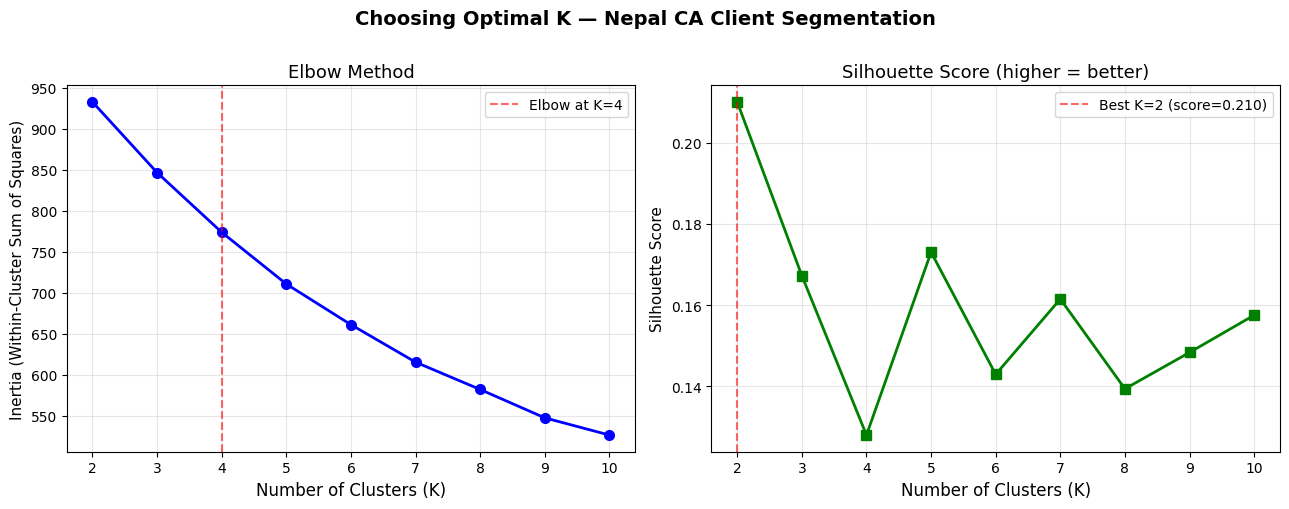

K  | Inertia    | Silhouette
--------------------------------
 2 |      932.7 | 0.2101 <-- best
 3 |      846.5 | 0.1672
 4 |      773.6 | 0.1279
 5 |      710.5 | 0.1730
 6 |      660.9 | 0.1429
 7 |      615.1 | 0.1615
 8 |      581.8 | 0.1393
 9 |      547.2 | 0.1483
10 |      526.1 | 0.1575


In [4]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Choosing Optimal K — Nepal CA Client Segmentation',
             fontsize=14, fontweight='bold', y=1.01)

# Elbow plot
ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='Elbow at K=4')
ax1.legend()

# Silhouette plot
ax2.plot(list(k_range), sil_scores, 'gs-', linewidth=2, markersize=7)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score (higher = better)', fontsize=13)
ax2.grid(True, alpha=0.3)
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
ax2.axvline(x=best_k, color='red', linestyle='--', alpha=0.6,
            label=f'Best K={best_k} (score={max(sil_scores):.3f})')
ax2.legend()

plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=120, bbox_inches='tight')
plt.show()

print('K  | Inertia    | Silhouette')
print('-' * 32)
for k, ine, sil in zip(k_range, inertias, sil_scores):
    marker = ' <-- best' if k == best_k else ''
    print(f'{k:2} | {ine:10.1f} | {sil:.4f}{marker}')


## Section 9: Fit K-Means & Label Clients

Based on the elbow and silhouette plots, we'll use **K=4** —  
four behavioural segments are interpretable and meaningful for a CA practice.

In [5]:
K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
client_df['Cluster'] = km_final.fit_predict(X_scaled)

# Cluster sizes
sizes = client_df['Cluster'].value_counts().sort_index()
print('Cluster sizes:')
for c, n in sizes.items():
    pct = n / len(client_df) * 100
    print(f'  Cluster {c}: {n:3d} clients ({pct:.1f}%)')

# Cluster centroids (un-scaled for interpretability)
centroids_scaled = km_final.cluster_centers_
centroids_df = pd.DataFrame(
    scaler.inverse_transform(centroids_scaled),
    columns=FEATURES
).round(2)
centroids_df.index.name = 'Cluster'
print()
print('Cluster Centroids (original scale):')
print(centroids_df.to_string())


Cluster sizes:
  Cluster 0:  46 clients (23.2%)
  Cluster 1:  61 clients (30.8%)
  Cluster 2:  40 clients (20.2%)
  Cluster 3:  51 clients (25.8%)

Cluster Centroids (original scale):
         avg_delay  late_rate  avg_invoice  tenure_years  credit_days  risk_score
Cluster                                                                          
0            26.68       0.17    908140.35          3.18        40.53        0.30
1            16.72       0.09    747302.21          5.10        39.63        0.25
2            73.54       0.65    970720.55          4.36        39.71        0.32
3            48.61       0.40    646038.70          4.60        43.40        0.25


## Section 10: Visualise Clusters (PCA)

With 6 features we can't plot clusters directly. **PCA (Principal Component Analysis)**  
compresses the 6D space into 2D for visualisation — it's not a model, just a lens.

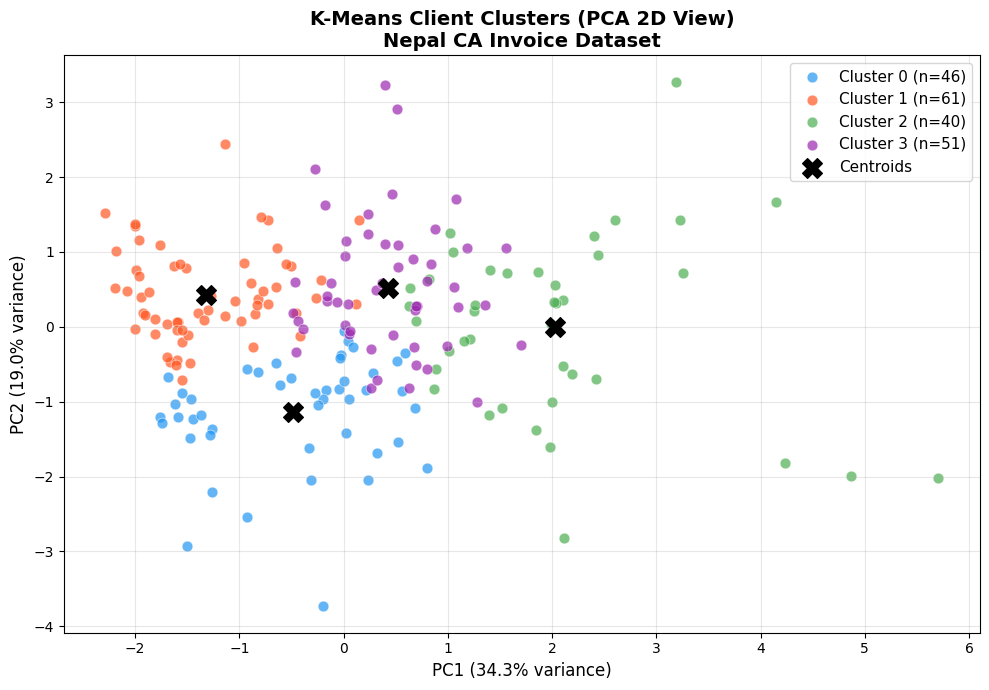

Variance captured by 2 components: 53.4%


In [6]:
# Reduce to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_

client_df['PC1'] = X_2d[:, 0]
client_df['PC2'] = X_2d[:, 1]

PALETTE = {0: '#2196F3', 1: '#FF5722', 2: '#4CAF50', 3: '#9C27B0'}
CLUSTER_NAMES = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
}

fig, ax = plt.subplots(figsize=(10, 7))

for c in range(K_FINAL):
    mask = client_df['Cluster'] == c
    ax.scatter(
        client_df.loc[mask, 'PC1'],
        client_df.loc[mask, 'PC2'],
        c=PALETTE[c], label=f'Cluster {c} (n={mask.sum()})',
        alpha=0.7, s=60, edgecolors='white', linewidths=0.5
    )

# Plot centroids in PCA space
centroids_2d = pca.transform(centroids_scaled)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('K-Means Client Clusters (PCA 2D View)\nNepal CA Invoice Dataset',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Variance captured by 2 components: {sum(var_explained)*100:.1f}%')


## Section 11: Profile Each Cluster

Now we interpret what each cluster *means* by looking at the average feature  
values per cluster. This is where the analytics becomes actionable insight.

In [7]:
# Cluster mean profile
profile = (
    client_df.groupby('Cluster')[FEATURES + ['total_invoices']]
    .mean()
    .round(2)
)
profile.columns = ['Avg Delay (days)', 'Late Rate', 'Avg Invoice (NPR)',
                    'Tenure (yrs)', 'Credit Days', 'Risk Score', 'Total Invoices']
print('=== Cluster Profiles ===')
print(profile.to_string())
print()

# Industry distribution per cluster
print('=== Top Industry per Cluster ===')
for c in range(K_FINAL):
    top_ind = client_df[client_df['Cluster'] == c]['Industry'].value_counts().head(3)
    ind_str = ', '.join([f'{i} ({n})' for i, n in top_ind.items()])
    print(f'  Cluster {c}: {ind_str}')


=== Cluster Profiles ===
         Avg Delay (days)  Late Rate  Avg Invoice (NPR)  Tenure (yrs)  Credit Days  Risk Score  Total Invoices
Cluster                                                                                                       
0                   26.68       0.17          908140.35          3.18        40.53        0.30            4.70
1                   16.72       0.09          747302.21          5.10        39.63        0.25            4.39
2                   73.54       0.65          970720.55          4.36        39.71        0.32            4.20
3                   48.61       0.40          646038.70          4.60        43.40        0.25            4.86

=== Top Industry per Cluster ===
  Cluster 0: Trading & Import (11), Construction (8), Manufacturing (7)
  Cluster 1: Manufacturing (13), Trading & Import (10), Tourism & Hotels (9)
  Cluster 2: Trading & Import (18), Tourism & Hotels (4), Manufacturing (4)
  Cluster 3: Trading & Import (11), Banking & Fina

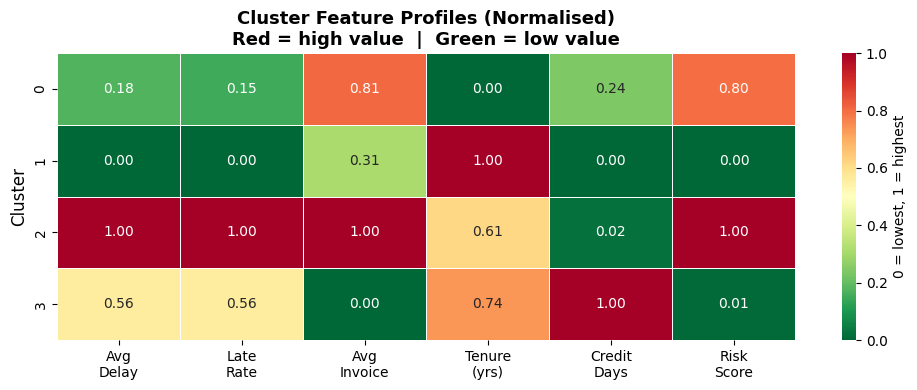

In [8]:
# Normalised feature heatmap — shows which features define each cluster
profile_norm = (
    client_df.groupby('Cluster')[FEATURES]
    .mean()
)
# Normalise each feature 0-1 so heatmap is comparable
profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())
profile_norm.columns = ['Avg\nDelay', 'Late\nRate', 'Avg\nInvoice',
                         'Tenure\n(yrs)', 'Credit\nDays', 'Risk\nScore']

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    profile_norm, annot=True, fmt='.2f', cmap='RdYlGn_r',
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    cbar_kws={'label': '0 = lowest, 1 = highest'}
)
ax.set_title('Cluster Feature Profiles (Normalised)\n'
             'Red = high value  |  Green = low value',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Cluster', fontsize=12)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


In [9]:
# Assign meaningful names based on profile
# (Run the profile cell above first — names may vary with your data)
profile_raw = (
    client_df.groupby('Cluster')[['avg_delay','late_rate','avg_invoice','risk_score']]
    .mean()
)

# Sort clusters by risk score to assign labels robustly
risk_order = profile_raw['risk_score'].rank().astype(int)

LABEL_MAP = {}
for c in range(K_FINAL):
    rank = risk_order[c]
    delay = profile_raw.loc[c, 'avg_delay']
    late  = profile_raw.loc[c, 'late_rate']
    score = profile_raw.loc[c, 'risk_score']
    size  = profile_raw.loc[c, 'avg_invoice']
    if rank == 1:
        label = 'Platinum — Reliable'
    elif rank == 2:
        label = 'Gold — Stable'
    elif rank == 3:
        label = 'Silver — Monitor'
    else:
        label = 'Red — High Risk'
    LABEL_MAP[c] = label
    print(f'Cluster {c} → {label:25s}  '
          f'delay={delay:.1f}d, late={late:.0%}, risk={score:.3f}')

client_df['Segment'] = client_df['Cluster'].map(LABEL_MAP)
print()
print('Segment counts:')
print(client_df['Segment'].value_counts().to_string())


Cluster 0 → Silver — Monitor           delay=26.7d, late=17%, risk=0.304
Cluster 1 → Platinum — Reliable        delay=16.7d, late=9%, risk=0.252
Cluster 2 → Red — High Risk            delay=73.5d, late=65%, risk=0.318
Cluster 3 → Gold — Stable              delay=48.6d, late=40%, risk=0.253

Segment counts:
Segment
Platinum — Reliable    61
Gold — Stable          51
Silver — Monitor       46
Red — High Risk        40


## Section 12: Collection Strategy by Segment

The real value of segmentation is **acting differently on each group**.  
Here we generate a tailored AR collection strategy for each cluster.

=== AR Collection Strategy by Segment ===
Segment                      Clients Action
----------------------------------------------------------------------
Platinum — Reliable               61  Auto-process, annual review
Gold — Stable                     51  Quarterly check-in, soft nudge
Silver — Monitor                  46  Monthly follow-up, tighten terms
Red — High Risk                   40  Weekly chase, require advance


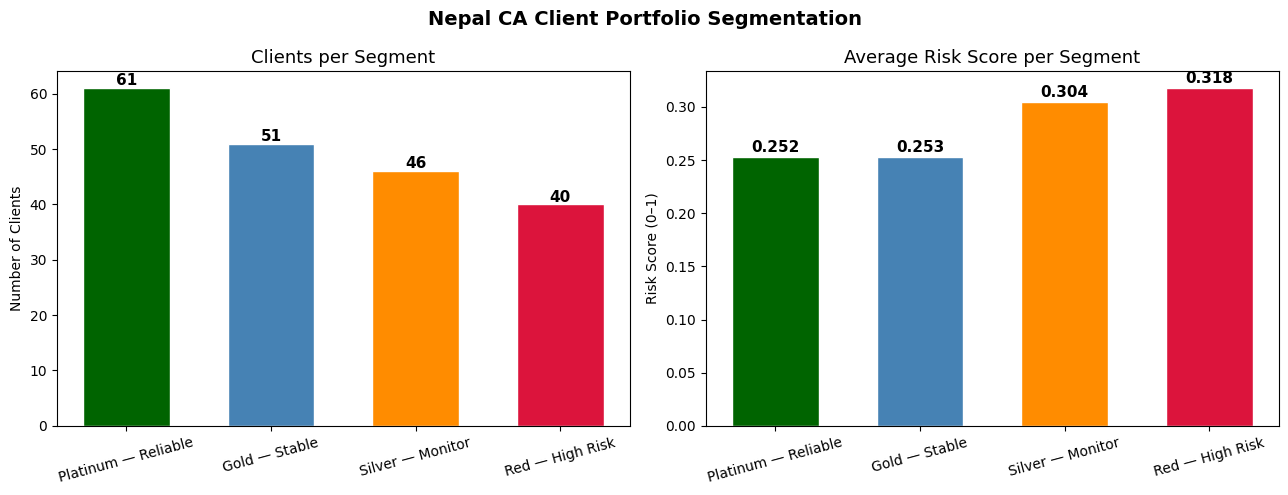

In [10]:
STRATEGY = {
    'Platinum — Reliable':  ('Auto-process, annual review',   'darkgreen'),
    'Gold — Stable':        ('Quarterly check-in, soft nudge', 'steelblue'),
    'Silver — Monitor':     ('Monthly follow-up, tighten terms','darkorange'),
    'Red — High Risk':      ('Weekly chase, require advance',  'crimson'),
}

print('=== AR Collection Strategy by Segment ===')
print(f'{"Segment":<28} {"Clients":>7} {"Action"}')
print('-' * 70)
for seg, (action, _) in STRATEGY.items():
    n = (client_df['Segment'] == seg).sum()
    print(f'{seg:<28} {n:>7}  {action}')

# Visualise segment distribution
seg_counts = client_df['Segment'].value_counts()
colors = [STRATEGY[s][1] for s in seg_counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Nepal CA Client Portfolio Segmentation',
             fontsize=14, fontweight='bold')

# Bar chart — client count
bars = ax1.bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white', width=0.6)
ax1.set_title('Clients per Segment', fontsize=13)
ax1.set_ylabel('Number of Clients')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=15)
for bar, v in zip(bars, seg_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v),
             ha='center', fontsize=11, fontweight='bold')

# Average risk score per segment
seg_risk = client_df.groupby('Segment')['risk_score'].mean().reindex(seg_counts.index)
bars2 = ax2.bar(seg_risk.index, seg_risk.values, color=colors, edgecolor='white', width=0.6)
ax2.set_title('Average Risk Score per Segment', fontsize=13)
ax2.set_ylabel('Risk Score (0–1)')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=15)
for bar, v in zip(bars2, seg_risk.values):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.005,
             f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('segment_strategy.png', dpi=120, bbox_inches='tight')
plt.show()


---

## Part 4: Finance Applications

---

## Section 13: AR Aging Segmentation

A classic CA task: group outstanding invoices by **how long they've been overdue**.  
Traditional aging buckets (0–30, 31–60, 61–90, 90+) are fixed by convention.  
K-Means can discover **natural aging groups** from your data — they may not align  
with convention but can reveal real payment behaviour patterns.

Here we simulate an AR aging analysis on outstanding invoices.

=== AR Aging Clusters ===
            Count  Avg_Days  Avg Amount  Total (NPR M)
AR_Cluster                                            
0              44      79.0    353960.0          15.57
1              21     208.0    624345.0          13.11
2               7     283.0   1306621.0           9.15
3              78      21.0    150862.0          11.77


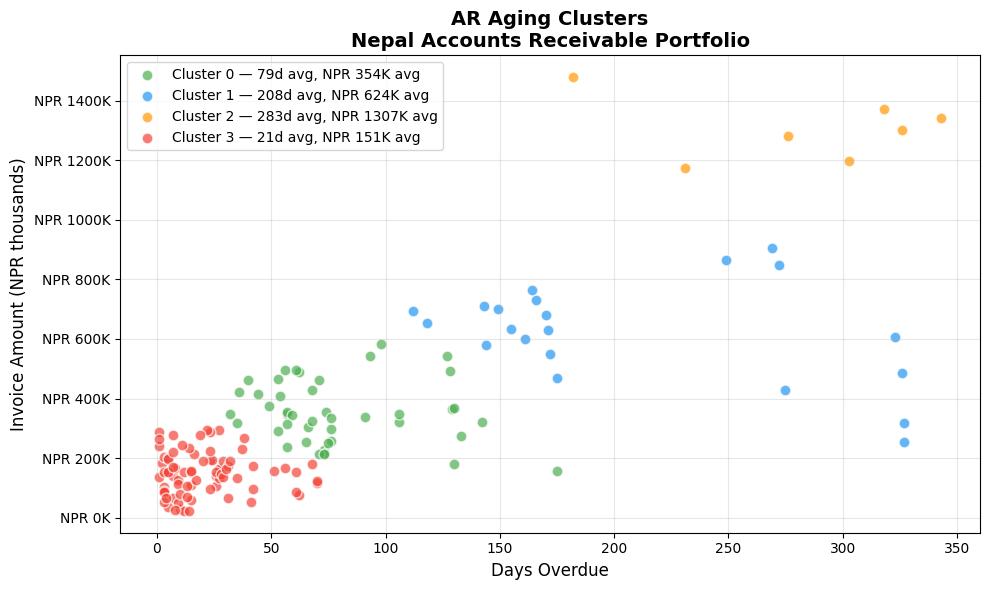

In [11]:
np.random.seed(42)
n_outstanding = 150

# Simulate outstanding invoices with realistic Nepal B2B payment patterns
ar_df = pd.DataFrame({
    'Invoice_ID':     [f'AR-{i:04d}' for i in range(1, n_outstanding+1)],
    'Client':         np.random.choice(
        ['Himalayan Trading', 'Everest Pharma', 'Kathmandu Builders',
         'Pokhara Retail', 'NMB Leasing', 'Ncell Resellers',
         'Birgunj Imports', 'Janakpur Mills'],
        n_outstanding
    ),
    'Days_Overdue':   np.concatenate([
        np.random.randint(1, 30, 60),      # current — 40%
        np.random.randint(30, 75, 45),     # 30-75 days — 30%
        np.random.randint(75, 180, 30),    # 75-180 days — 20%
        np.random.randint(180, 365, 15),   # >180 days — 10%
    ]),
    'Amount_NPR':     np.concatenate([
        np.random.randint(20000, 300000, 60),
        np.random.randint(50000, 500000, 45),
        np.random.randint(100000, 800000, 30),
        np.random.randint(200000, 1500000, 15),
    ]),
})

# Cluster on Days_Overdue and Amount
X_ar = StandardScaler().fit_transform(ar_df[['Days_Overdue', 'Amount_NPR']])
km_ar = KMeans(n_clusters=4, random_state=42, n_init=10)
ar_df['AR_Cluster'] = km_ar.fit_predict(X_ar)

# Profile AR clusters
ar_profile = ar_df.groupby('AR_Cluster').agg(
    Count=('Invoice_ID', 'count'),
    Avg_Days=('Days_Overdue', 'mean'),
    Total_NPR=('Amount_NPR', 'sum'),
    Avg_NPR=('Amount_NPR', 'mean'),
).round(0)
ar_profile['Total_NPR_M'] = (ar_profile['Total_NPR'] / 1_000_000).round(2)
print('=== AR Aging Clusters ===')
print(ar_profile[['Count','Avg_Days','Avg_NPR','Total_NPR_M']]
      .rename(columns={'Avg_NPR':'Avg Amount','Total_NPR_M':'Total (NPR M)'})
      .to_string())

# Scatter plot
ar_colors = {0:'#4CAF50', 1:'#2196F3', 2:'#FF9800', 3:'#F44336'}
fig, ax = plt.subplots(figsize=(10, 6))
for c in range(4):
    mask = ar_df['AR_Cluster'] == c
    m = ar_profile.loc[c]
    ax.scatter(
        ar_df.loc[mask, 'Days_Overdue'],
        ar_df.loc[mask, 'Amount_NPR'] / 1000,
        c=ar_colors[c], s=60, alpha=0.7, edgecolors='white',
        label=f'Cluster {c} — {int(m["Avg_Days"])}d avg, '
              f'NPR {m["Avg_NPR"]/1000:.0f}K avg'
    )
ax.set_xlabel('Days Overdue', fontsize=12)
ax.set_ylabel('Invoice Amount (NPR thousands)', fontsize=12)
ax.set_title('AR Aging Clusters\nNepal Accounts Receivable Portfolio',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'NPR {x:.0f}K'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ar_aging_clusters.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 14: Export Cluster Labels to Excel

Export the segmented client list to Excel — ready to hand to the collection team  
or load into Tally/accounting software for priority follow-up.

In [12]:
export_df = (
    client_df[['Client_ID', 'Client_Name', 'Industry', 'Province',
               'Cluster', 'Segment', 'avg_delay', 'late_rate',
               'avg_invoice', 'tenure_years', 'credit_days', 'risk_score']]
    .rename(columns={
        'avg_delay':    'Avg_Delay_Days',
        'late_rate':    'Late_Payment_Rate',
        'avg_invoice':  'Avg_Invoice_NPR',
        'tenure_years': 'Tenure_Years',
        'credit_days':  'Credit_Days',
        'risk_score':   'Risk_Score',
    })
    .sort_values(['Cluster', 'Risk_Score'], ascending=[True, False])
)

output_file = 'nepal_client_segments.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    export_df.to_excel(writer, sheet_name='Client Segments', index=False)
    client_df.groupby('Segment')[FEATURES].mean().round(2)\
             .to_excel(writer, sheet_name='Segment Profiles')
    ar_df.to_excel(writer, sheet_name='AR Aging Clusters', index=False)

print(f'Exported to {output_file}')
print(f'  Sheet 1: Client Segments    — {len(export_df)} rows')
print(f'  Sheet 2: Segment Profiles   — cluster feature means')
print(f'  Sheet 3: AR Aging Clusters  — {len(ar_df)} outstanding invoices')
print()
print('Preview — first 5 rows of export:')
print(export_df.head().to_string(index=False))


Exported to nepal_client_segments.xlsx
  Sheet 1: Client Segments    — 198 rows
  Sheet 2: Segment Profiles   — cluster feature means
  Sheet 3: AR Aging Clusters  — 150 outstanding invoices

Preview — first 5 rows of export:
Client_ID                 Client_Name         Industry      Province  Cluster          Segment  Avg_Delay_Days  Late_Payment_Rate  Avg_Invoice_NPR  Tenure_Years  Credit_Days  Risk_Score
   NP0040   Everest Imports Pvt. Ltd. Trading & Import       Gandaki        0 Silver — Monitor           16.00               0.00        917000.00      1.850000         60.0    0.452300
   NP0005    Pokhara Construction Co.     Construction       Madhesh        0 Silver — Monitor            8.20               0.00       1034000.00      2.806000         39.0    0.420500
   NP0184 Himalayan Traders Pvt. Ltd. Trading & Import       Gandaki        0 Silver — Monitor           46.67               0.33        500333.33      3.376667         35.0    0.409200
   NP0115     Sagarmatha Trekk

---

## Part 5: Practice Exercises

---

## Section 15: Exercises

### Exercise 1 — Change K and Compare
Re-run K-Means with K=3 and K=5. How do the segment profiles change?  
Which K gives more actionable segments for a CA practice?

### Exercise 2 — Province-wise Segmentation
Filter clients to **Bagmati Province** only and re-run the full segmentation.  
Do the clusters look different from the national picture? Why might that be?

### Exercise 3 — Add a Feature
Add `total_invoices` (number of invoices per client) as a 7th clustering feature.  
Re-run elbow + silhouette. Does the optimal K change?

### Exercise 4 — Expense Clustering
Using the data below, cluster 12 months of company expenses into natural groups.  
Identify which months form the "high spend" cluster.

```python
expense_data = pd.DataFrame({
    'Month':    ['Shrawan','Bhadra','Ashwin','Kartik','Mangsir','Poush',
                 'Magh','Falgun','Chaitra','Baishakh','Jestha','Ashadh'],
    'Salary':   [1200000,1200000,1200000,1300000,1200000,1250000,
                 1200000,1200000,1300000,1200000,1200000,1350000],
    'Rent':     [85000]*12,
    'Travel':   [45000,38000,62000,120000,35000,28000,
                 32000,55000,78000,95000,42000,115000],
    'Marketing':[30000,35000,25000,180000,20000,15000,
                 18000,22000,45000,90000,38000,75000],
})
```

---
### 💡 Solutions

In [13]:
# Exercise 1 — K=3 vs K=5
for k in [3, 5]:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_test.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f'K={k}: silhouette={sil:.4f}')
    sizes = pd.Series(labels).value_counts().sort_index().values
    print(f'  Cluster sizes: {sizes}')


K=3: silhouette=0.1672
  Cluster sizes: [42 92 64]
K=5: silhouette=0.1730
  Cluster sizes: [52 34 73  3 36]


In [14]:
# Exercise 2 — Bagmati Province only
bagmati = client_df[client_df['Province'] == 'Bagmati'].copy()
X_bag = StandardScaler().fit_transform(bagmati[FEATURES])

sil_bag = []
for k in range(2, 6):
    km_b = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_bag.append(silhouette_score(X_bag, km_b.fit_predict(X_bag)))

best_k_bag = range(2, 6)[sil_bag.index(max(sil_bag))]
print(f'Bagmati Province: {len(bagmati)} clients')
print(f'Best K for Bagmati: {best_k_bag} (silhouette={max(sil_bag):.4f})')
km_b = KMeans(n_clusters=best_k_bag, random_state=42, n_init=10)
bagmati['Cluster'] = km_b.fit_predict(X_bag)
print(bagmati.groupby('Cluster')[['avg_delay','late_rate','risk_score']].mean().round(3))


Bagmati Province: 63 clients
Best K for Bagmati: 2 (silhouette=0.2060)
         avg_delay  late_rate  risk_score
Cluster                                  
0           68.503       0.60       0.297
1           27.263       0.19       0.258


In [15]:
# Exercise 3 — Add total_invoices as 7th feature
FEATURES7 = FEATURES + ['total_invoices']
X7 = StandardScaler().fit_transform(client_df[FEATURES7])

k_range = range(2, 8)
sil7 = [silhouette_score(X7, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X7))
        for k in k_range]

best_k7 = list(k_range)[sil7.index(max(sil7))]
print(f'With 7 features — Best K: {best_k7} (silhouette={max(sil7):.4f})')
print('Silhouette by K:', {k: round(s, 4) for k, s in zip(k_range, sil7)})


With 7 features — Best K: 2 (silhouette=0.1846)
Silhouette by K: {2: 0.1846, 3: 0.1549, 4: 0.1274, 5: 0.1491, 6: 0.1424, 7: 0.1553}


In [16]:
# Exercise 4 — Expense clustering
expense_data = pd.DataFrame({
    'Month':    ['Shrawan','Bhadra','Ashwin','Kartik','Mangsir','Poush',
                 'Magh','Falgun','Chaitra','Baishakh','Jestha','Ashadh'],
    'Salary':   [1200000,1200000,1200000,1300000,1200000,1250000,
                 1200000,1200000,1300000,1200000,1200000,1350000],
    'Rent':     [85000]*12,
    'Travel':   [45000,38000,62000,120000,35000,28000,
                 32000,55000,78000,95000,42000,115000],
    'Marketing':[30000,35000,25000,180000,20000,15000,
                 18000,22000,45000,90000,38000,75000],
})

X_exp = StandardScaler().fit_transform(expense_data[['Salary','Rent','Travel','Marketing']])
km_exp = KMeans(n_clusters=3, random_state=42, n_init=10)
expense_data['Cluster'] = km_exp.fit_predict(X_exp)

print('Expense Clusters:')
print(expense_data.groupby('Cluster')['Month'].apply(list).to_string())
print()
print(expense_data.groupby('Cluster')[['Salary','Travel','Marketing']].mean()
      .round(0).to_string())


Expense Clusters:
Cluster
0                                   [Kartik, Baishakh]
1    [Shrawan, Bhadra, Ashwin, Mangsir, Poush, Magh...
2                                    [Chaitra, Ashadh]

            Salary    Travel  Marketing
Cluster                                
0        1250000.0  107500.0   135000.0
1        1206250.0   42125.0    25375.0
2        1325000.0   96500.0    60000.0
